Work on the same dataset as last time.
Download from [here](https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation-clustering).




In [1]:
# Import the dataset
import numpy as np

X = np.genfromtxt('customer_segmentation.csv', delimiter=',')
X = X[~np.isnan(X).all(axis=1),:]
X = X[:,~np.isnan(X).any(axis=0)]

Compute the distance matrix for all samples in the dataset.

(2240, 2240)
2152.288549428259


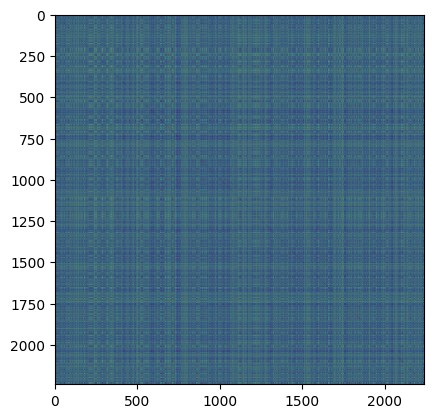

In [ ]:
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# Using Euclidian distance
dist_matrix_euclid = squareform(pdist(X, metric='euclidean'))

print(dist_matrix_euclid.shape)
print(dist_matrix_euclid[4,5])

# Using Manhattan distance
dist_matrix_manhattan = squareform(pdist(X, metric='cityblock'))

# Using cosine similarity
dist_matrix_cosine = squareform(pdist(X, metric='cosine'))

# Using correlation
dist_matrix_correlation = squareform(pdist(X, metric='correlation'))

# Plot the distance matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
distance_data = [
    (dist_matrix_euclid, 'Euclidean'),
    (dist_matrix_manhattan, 'Manhattan'),
    (dist_matrix_cosine, 'Cosine'),
    (dist_matrix_correlation, 'Correlation'),
]
for ax, (matrix, title) in zip(axes.flat, distance_data):
    im = ax.imshow(matrix, aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


Perform hierarchical clustering on the dataset.

/var/folders/q4/nf4zxcpx3n78xpqm7lrgxn8r0000gn/T/ipykernel_73668/1566594990.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_euclid, method = 'ward')


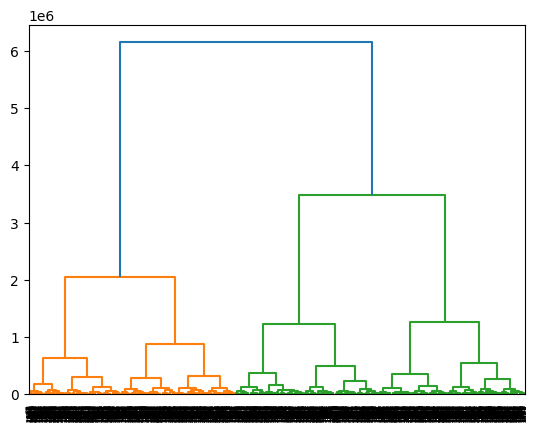

In [3]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(dist_matrix_euclid, method = 'ward')

# Example for plotting the dendogram using one of the distances matrix
plt.figure()
dendrogram(Z)
plt.show()

Based on the dendogram, choose the optimal number of clusters and apply kmeans.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Based on the dendrogram, choose the optimal number of clusters
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title(f'KMeans Clustering (k={n_clusters}) - PCA Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


Use the other three distance metrics to perform clustering and plot the dendograms in 2 by 2 subplots.

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

distance_matrices = [
    (dist_matrix_euclid, 'Euclidean'),
    (dist_matrix_manhattan, 'Manhattan'),
    (dist_matrix_cosine, 'Cosine'),
    (dist_matrix_correlation, 'Correlation'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (dist_matrix, title) in zip(axes.flat, distance_matrices):
    Z = linkage(dist_matrix, method='ward')
    dendrogram(Z, ax=ax, no_labels=True)
    ax.set_title(f'Dendrogram - {title} Distance')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


Use different linking functions and compare results.
As per scikit learn documentation, the clustering function accepts the following types of linkages:
- 'ward' minimizes the variance of the clusters being merged.
- 'average' uses the average of the distances of each observation of the two sets.
- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.
- 'single' uses the minimum of the distances between all observations of the two sets.





In [ ]:
linkage_methods = ['ward', 'average', 'complete', 'single']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, method in zip(axes.flat, linkage_methods):
    Z = linkage(dist_matrix_euclid, method=method)
    dendrogram(Z, ax=ax, no_labels=True)
    ax.set_title(f'Dendrogram - {method.capitalize()} Linkage')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()
